In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

In [3]:
vehicles = pd.read_csv("US_Accidents_March23_sampled_500k.csv", index_col=0)
df = vehicles.copy()

In [4]:
df

,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
ID,,,,,,,,,,,,,,,,,,,,,
A-2047758,Source2,2,2019-06-12 10:10:56,2019-06-12 10:55:58,30.641211,-91.153481,NaN,NaN,0.000,Accident on LA-19 Baker-Zachary Hwy at Lower Z...,...,False,False,False,False,True,False,Day,Day,Day,Day
A-4694324,Source1,2,2022-12-03 23:37:14.000000000,2022-12-04 01:56:53.000000000,38.990562,-77.399070,38.990037,-77.398282,0.056,Incident on FOREST RIDGE DR near PEPPERIDGE PL...,...,False,False,False,False,False,False,Night,Night,Night,Night
A-5006183,Source1,2,2022-08-20 13:13:00.000000000,2022-08-20 15:22:45.000000000,34.661189,-120.492822,34.661189,-120.492442,0.022,Accident on W Central Ave from Floradale Ave t...,...,False,False,False,False,True,False,Day,Day,Day,Day
A-4237356,Source1,2,2022-02-21 17:43:04,2022-02-21 19:43:23,43.680592,-92.993317,43.680574,-92.972223,1.054,Incident on I-90 EB near REST AREA Drive with ...,...,False,False,False,False,False,False,Day,Day,Day,Day
A-6690583,Source1,2,2020-12-04 01:46:00,2020-12-04 04:13:09,35.395484,-118.985176,35.395476,-118.985995,0.046,RP ADV THEY LOCATED SUSP VEH OF 20002 - 726 CR...,...,False,False,False,False,False,False,Night,Night,Night,Night
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A-6077227,Source1,2,2021-12-15 07:30:00,2021-12-15 07:50:30,45.522510,-123.084104,45.520225,-123.084211,0.158,Stationary traffic on OR-47 from NW Martin Rd ...,...,False,False,False,False,False,False,Night,Day,Day,Day
A-6323243,Source1,2,2021-12-19 16:25:00,2021-12-19 17:40:37,26.702570,-80.111169,26.703141,-80.111133,0.040,Incident on MILITARY TRL near WESTGATE AVE Dri...,...,False,False,False,False,False,False,Day,Day,Day,Day
A-3789256,Source1,2,2022-04-13 19:28:29,2022-04-13 21:33:44,34.561862,-112.259620,34.566822,-112.267150,0.549,Crash on the right shoulder on E SR-69 Northbo...,...,False,False,False,False,True,False,Night,Night,Day,Day


In [5]:
df.isnull().sum()

Source                        0
Severity                      0
Start_Time                    0
End_Time                      0
Start_Lat                     0
Start_Lng                     0
End_Lat                  220377
End_Lng                  220377
Distance(mi)                  0
Description                   1
Street                      691
City                         19
County                        0
State                         0
Zipcode                     116
Country                       0
Timezone                    507
Airport_Code               1446
Weather_Timestamp          7674
Temperature(F)            10466
Wind_Chill(F)            129017
Humidity(%)               11130
Pressure(in)               8928
Visibility(mi)            11291
Wind_Direction            11197
Wind_Speed(mph)           36987
Precipitation(in)        142616
Weather_Condition         11101
Amenity                       0
Bump                          0
Crossing                      0
Give_Way

In [6]:
# So to start with lets identify the obvious columns that we do not want to work with since it is irrelevant for our purposes of classifying the severity of accidents
df = df.drop(columns=[
    'Source', # Where the data is sourced from
    # We dont want any of the coordinates we have the country, county and street, state, they are derived from the coordinates
    'Start_Lat', 
    'Start_Lng', 
    'End_Lat', 
    'End_Lng', 
    'Country', # 100% of the values in Country is the US and we know that this dataset is from the US so we can take it out 
    'Airport_Code', # No need for this one
    'Timezone', # We do not need a timezone such as US/Cental or US/Pacific since we want to know what time of day is relevant at each place
    'Description', # We dont need the human language description it adds no value since it just states that an accident happened in a specific county
    'Wind_Direction' # This feature does not really add much since if wind_speed is 0 it says CALM but we get that from the wind speed and if its >0 it only shows direction, this would not have an effect on cars
])

In [7]:
# Location information could be important especially when gaining insights into accidents but for our model these add redundancy
# Since Street is inside of a City which is inside of a State, its the same information but some are broader and some are more specific
# We are looking at Street, City, County, State, Zipcode
# Ideally we would like to identify 1 that is most descriptive and drop the rest
# Especially if we want to compare the accident data to population it could be best to keep only the State
print(df['Street'].value_counts().describe()) # 88273 unique streets and most streets only appear a few times this does not generalize well and probably introduces noise
print(df['City'].value_counts().describe()) # 9489 unique cities, most appear a few times so could generalize well and is fairly balanced 
print(df['County'].value_counts().describe()) # This has much fewer unique values as expected but is not as precise as city
print(df['State'].value_counts().describe()) # 49 states in this dataset so we are missing one, this is not as precise, could work well for analysis but to start with we want to try City
print(df['Zipcode'].value_counts().describe()) # 127805 zip codes is too many to generalize well

# In conclusion, to start with we want to see if we can use city since it has enough unique values to be somewhat precise and capture some similarities but not too few to be too sparse, we might switch to State later
df = df.drop(columns=[
    'Street',
    'County', 
    'State', 
    'Zipcode', 
])

count    88272.000000
mean         5.656482
std         49.408383
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max       4973.000000
Name: count, dtype: float64
count     9488.000000
mean        52.696142
std        321.112628
min          1.000000
25%          2.000000
50%          6.000000
75%         25.000000
max      12141.000000
Name: count, dtype: float64
count     1606.000000
mean       311.332503
std       1337.224065
min          1.000000
25%          4.000000
50%         22.000000
75%        125.000000
max      34247.000000
Name: count, dtype: float64
count        49.000000
mean      10204.081633
std       18368.889024
min          19.000000
25%        1207.000000
50%        5025.000000
75%       10904.000000
max      113274.000000
Name: count, dtype: float64
count    127804.000000
mean          3.911333
std          17.358129
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         720

In [8]:
# Next we have the timestamps
# We want to keep the Start_Time thats very important to know but we need to convert it into useable time units
df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='mixed')

df['Start_Hour'] = df['Start_Time'].dt.hour
df['Start_DayOfWeek'] = df['Start_Time'].dt.dayofweek
df['Start_Month'] = df['Start_Time'].dt.month
df['Start_Year'] = df['Start_Time'].dt.year
df['Start_Is_Weekend'] = df['Start_DayOfWeek'].isin([5,6]).astype(int) # Also add an additional column it might be useful to see the accident spread on weekends vs weekdays
df['Start_Time'].isnull().sum()
# End_Time is tricky because we can calculate the duration of the crash (End_Time - Start_time) but that is most likely highly correlated with severity, and since we want to predict severity we
# Wouldnt know the endtime or duration beforehand, so for the prediction model we should drop this timestamp all together, otherwise the model could just say that the best indicator is a long duration...
df = df.drop(columns=['End_Time']) # We drop it now but will be useful in analysis or estimating the impact certain severities have
# Now for the Weather Timestamp, that is the time we recorded the weather conditions at the airport nearest the accident site, intuatively this would not matter for the severity
# The only thing we want to check with this is if the weather timestamp is a long time after or before the accident happened, if so we should maybe drop those rows since the weather conditions could have been much different at the time of the accident
df['Weather_Timestamp'] = pd.to_datetime(df['Weather_Timestamp'], format='mixed')
df['Weather_Time_Diff_Min'] = (
    (df['Start_Time'] - df['Weather_Timestamp'])
    .dt.total_seconds() / 60
)
# Check the difference between the weather timestamp and start timestamp (in min)
print(df['Weather_Time_Diff_Min'].describe())
df['Weather_Time_Diff_Min'].abs().quantile([0.5, 0.9, 0.95, 0.99])
# We need to decide on a threshold, i.e what is too far away to trust
# From the quantile distribution we can see that 95% are under 30 min away (29) we can safely trust these even at the 99% percentile we have under 90 min which is probably fine
# We do want to remove the extremes we see the minimum value of -1432 min and max of 1398 this is definitely too far away so lets check how many values are above the abs value of 2 hours, 3 hours, 4 hours
thresholds = [120, 180, 240, 360]  # 2h, 3h, 4h, 6h

for t in thresholds:
    count = (df['Weather_Time_Diff_Min'].abs() > t).sum()
    pct = (count / len(df)) * 100
    print(f">{t} min: {count} rows ({pct:.2f}%)")
# We can see 0.82% for above 2 hours, 0.60% for above 3 hours and 0.46% for above 4 hours. Before we drop anything lets see if they correlate with severity.
df['Weather_Diff_Bin'] = pd.cut(
    df['Weather_Time_Diff_Min'].abs(),
    bins=[0, 30, 60, 120, 240, 1440],
    labels=['0-30', '30-60', '60-120', '120-240', '240+']
)
print(pd.crosstab(df['Weather_Diff_Bin'], df['Severity'], normalize='index'))
# Well higher severity is associated with a longer difference but not for the extreme values so 240+ min so lets safely remove all the rows that are above 240 min that is well above our 99% quantile
# and only 0.46% of our data and we are unsure of if we can trust it since a 4 hour difference can make the difference between sunny and cloudy with severe rain,
df = df[df['Weather_Time_Diff_Min'].abs() <= 240] # Drop the rows where the difference is 240 min
df = df.drop(columns=['Weather_Timestamp']) # Then drop the Weather_Timestamp since it has served its purpose and we dont need it for prediction
# Then drop the two columns we made for the analysis
df = df.drop(columns=['Weather_Diff_Bin'])
df = df.drop(columns=['Weather_Time_Diff_Min'])
df = df.drop(columns=['Start_Time']) # Finally drop the Start_Time since we already extracted the features from it

count    492326.000000
mean         -0.571787
std          41.572173
min       -1432.000000
25%         -11.450000
50%           0.000000
75%          11.050000
max        1398.000000
Name: Weather_Time_Diff_Min, dtype: float64
>120 min: 4093 rows (0.82%)
>180 min: 2996 rows (0.60%)
>240 min: 2319 rows (0.46%)
>360 min: 1328 rows (0.27%)
Severity                 1         2         3         4
Weather_Diff_Bin                                        
0-30              0.008702  0.795567  0.170052  0.025679
30-60             0.006062  0.787308  0.174900  0.031730
60-120            0.004380  0.769830  0.192214  0.033577
120-240           0.004510  0.754791  0.204622  0.036077
240+              0.007762  0.790858  0.169038  0.032342


In [9]:
# Next we have 7 numerical weather condition columns, we want to check if any are redundant so we will start by checking correlation between them
# Temperature, Wind_Chill, Humidity, Pressure, Visibility, Wind_Speed, Precipitation
corr = df[['Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)',
           'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 
           'Precipitation(in)']].corr()

print(corr)
# From the correlation matrix we see that Wind_Chill is very strongly correlated with Temperature p = 0.993741 we also know that about 1/4 of that column is missing so we will drop it
df = df.drop(columns=['Wind_Chill(F)'])

                   Temperature(F)  Wind_Chill(F)  Humidity(%)  Pressure(in)  \
Temperature(F)           1.000000       0.993752    -0.330854      0.108015   
Wind_Chill(F)            0.993752       1.000000    -0.314484      0.085218   
Humidity(%)             -0.330854      -0.314484     1.000000      0.119148   
Pressure(in)             0.108015       0.085218     0.119148      1.000000   
Visibility(mi)           0.213608       0.229818    -0.380673      0.035138   
Wind_Speed(mph)          0.033022      -0.044051    -0.171268     -0.023973   
Precipitation(in)       -0.004515      -0.011724     0.083426      0.017191   

                   Visibility(mi)  Wind_Speed(mph)  Precipitation(in)  
Temperature(F)           0.213608         0.033022          -0.004515  
Wind_Chill(F)            0.229818        -0.044051          -0.011724  
Humidity(%)             -0.380673        -0.171268           0.083426  
Pressure(in)             0.035138        -0.023973           0.017191  
Visibil

In [10]:
severity_counts = df['Severity'].value_counts().sort_index()
severity_percent = df['Severity'].value_counts(normalize=True).sort_index() * 100

summary = pd.DataFrame({
    'Count': severity_counts,
    'Percentage (%)': severity_percent.round(2)
})

print(summary)
# We can see that the data is heavily skewed with 80% of accidents being at severity 2

           Count  Percentage (%)
Severity                        
1           4208            0.86
2         390081           79.61
3          83027           16.94
4          12691            2.59


In [11]:
# We also have 4 different types of telling whether its day or night we want to check if we can drop all of them or all but one
# Sunrise_Sunset, Civil_Twilight, Nautical_Twilight, Astronomical_Twilight, They all have either Day or Night so well convert them to 0 and 1 and check correlations

for col in ['Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']:
    df[col] = df[col].map({'Day': 1, 'Night': 0})

corr = df[['Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']].corr()
print(corr)
# These as expected are all very correlated but keeping them all would be redundant since they all measure the same "lightness" level
# There are two options we could take here, the simpler one being just keeping the most intuative one, Sunrise_Sunset and dropping the rest
# The other one being some combination of at least the twilight columns creating a sort of Light_Score or Darkness column where we would convert all of them to binary encodings and add them together

# So for now we will drop the twiliht columns, since sunrise sunset is a hard cutoff of day and night and the rest is like a spectrum with astronomical twilight being the most strict.
df = df.drop(columns=['Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight'])

                       Sunrise_Sunset  Civil_Twilight  Nautical_Twilight  \
Sunrise_Sunset               1.000000        0.890523           0.775532   
Civil_Twilight               0.890523        1.000000           0.870823   
Nautical_Twilight            0.775532        0.870823           1.000000   
Astronomical_Twilight        0.679236        0.762761           0.875832   

                       Astronomical_Twilight  
Sunrise_Sunset                      0.679236  
Civil_Twilight                      0.762761  
Nautical_Twilight                   0.875832  
Astronomical_Twilight               1.000000  


In [12]:
# Next we have 13 True/False boolean features, viewing them at first glance we see that some of them are mostly False or atleast > 99.5% False
# But before we drop any of them prematurely we want to see if they are skewed towards severity, for example most of the True ones in the columns where 99.9% are False could be those that have severity 4
bool_cols = df.select_dtypes(include='bool').columns

for col in bool_cols:
    print(pd.crosstab(df[col], df['Severity'], normalize='index'))

# After checking the frequency of the True or False values with severity we can see that Turning_Loop is 100% False so we will just drop that column,
# Roundabout also has only True values in the most common class (severity 2) so its not tellig us anything so we will drop it.
df = df.drop(columns=['Roundabout', 'Turning_Loop'])

Severity         1         2         3         4
Amenity                                         
False     0.008516  0.794521  0.171008  0.025955
True      0.014279  0.919252  0.044970  0.021500
Severity         1         2         3         4
Bump                                            
False     0.008587  0.796040  0.169472  0.025900
True      0.009569  0.870813  0.095694  0.023923
Severity         1         2         3         4
Crossing                                        
False     0.007014  0.781752  0.183878  0.027356
True      0.020875  0.907922  0.056674  0.014528
Severity         1         2         3         4
Give_Way                                        
False     0.008548  0.795958  0.169639  0.025855
True      0.017038  0.820446  0.127130  0.035387
Severity         1         2         3         4
Junction                                        
False     0.008823  0.801906  0.164157  0.025114
True      0.005645  0.723195  0.235448  0.035712
Severity        1   

In [13]:
missing = df.isnull().sum().sort_values(ascending=False)

missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_%': (missing / len(df)) * 100,
    'Dtype': df.dtypes
})

missing_df = missing_df[missing_df['Missing_Count'] > 0]
#print(missing)
print(missing_df)

                   Missing_Count  Missing_%    Dtype
City                          19   0.003877      str
Humidity(%)                 3369   0.687541  float64
Precipitation(in)         133892  27.324508  float64
Pressure(in)                1213   0.247547  float64
Sunrise_Sunset              1318   0.268976  float64
Temperature(F)              2708   0.552645  float64
Visibility(mi)              3559   0.726316  float64
Weather_Condition           3356   0.684888      str
Wind_Speed(mph)            29027   5.923793  float64


In [14]:
# We have 5 numerical columns only ony has a missing value percentage of above 5% that is Wind_Speed(mph) so for the rest we will just fill the rest (4) with the column median
df['Temperature(F)'] = df['Temperature(F)'].fillna(df['Temperature(F)'].median())
df['Humidity(%)'] = df['Humidity(%)'].fillna(df['Humidity(%)'].median())
df['Pressure(in)'] = df['Pressure(in)'].fillna(df['Pressure(in)'].median())
df['Visibility(mi)'] = df['Visibility(mi)'].fillna(df['Visibility(mi)'].median())
df['Sunrise_Sunset'] = df['Sunrise_Sunset'].fillna(df['Sunrise_Sunset'].median())
# The categorical columns all have a very low percentage of missing values so well just fill them with unknown
df['City'] = df['City'].fillna("Unknown")
df['Weather_Condition'] = df['Weather_Condition'].fillna("Unknown")
# Columns we decided to drop but might bring back in later 
#df['Street'] = df['Street'].fillna("Unknown")
#df['Zipcode'] = df['Zipcode'].fillna("Unknown")

In [15]:
# For the more difficult columns Precipitation(in) with 28.5% missing values and Wind_Speed(mph) with 7.4% missing values
missing_precip_by_sev = df.groupby('Severity')['Precipitation(in)'].apply(
    lambda x: x.isnull().mean() * 100
)
print(missing_precip_by_sev)
print(df['Precipitation(in)'].value_counts())
# So for the precipitation we see that most of the values that are not missing is 0 which means no rain
# We do see that the missigness is not evenly spread across severity so we should probably add some missing indicator for this column and then fill it with 0
df['Precipitation_missing'] = df['Precipitation(in)'].isnull().astype(int) # 1 if value was missing from precipitation 0 otherwise
df['Precipitation(in)'] = df['Precipitation(in)'].fillna(0)
# And since Wind Speed also has a pretty large amount of missing values we will also create a msising indicator for it but instead of filling with 0 we will fill it with the median
df['Wind_Speed_missing'] = df['Wind_Speed(mph)'].isnull().astype(int)
df['Wind_Speed(mph)'] = df['Wind_Speed(mph)'].fillna(df['Wind_Speed(mph)'].median())

Severity
1     5.061787
2    22.913959
3    48.449300
4    32.069971
Name: Precipitation(in), dtype: float64
Precipitation(in)
0.00    321741
0.01      9703
0.02      4729
0.03      3213
0.04      2404
         ...  
2.31         1
1.15         1
1.89         1
4.89         1
1.39         1
Name: count, Length: 175, dtype: int64


In [16]:
# Final check if we still have any values that are missing
missing = df.isnull().sum().sort_values(ascending=False)
missing

Severity                 0
No_Exit                  0
Precipitation_missing    0
Start_Is_Weekend         0
Start_Year               0
Start_Month              0
Start_DayOfWeek          0
Start_Hour               0
Sunrise_Sunset           0
Traffic_Signal           0
Traffic_Calming          0
Stop                     0
Station                  0
Railway                  0
Junction                 0
Distance(mi)             0
Give_Way                 0
Crossing                 0
Bump                     0
Amenity                  0
Weather_Condition        0
Precipitation(in)        0
Wind_Speed(mph)          0
Visibility(mi)           0
Pressure(in)             0
Humidity(%)              0
Temperature(F)           0
City                     0
Wind_Speed_missing       0
dtype: int64

In [17]:
# We need to turn all the boolean (True/False) columns into 1/0 for the model
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [18]:
# Finally the last step to make the data ready for prediction are the two categorical columns City and Weather_Condition
# First City
print(df['City'].nunique())

city_counts = df['City'].value_counts()

print("Cities appearing only once:", (city_counts == 1).sum())
print("Cities appearing < 5 times:", (city_counts < 5).sum())

print(df['City'].value_counts())
# out of 9304 citites, 1836 appear only once and 3982 appear less than 5 times, one hot encoding would definitely not work here, it would produce too many columns and be sparse, target encoding would work but we are risking
# mixing information about the severity while training
# So we are going with frequency encoding, we can preserve the information about location density without exploding the feature space and it doesnt use the target variable
df['City_encoded'] = df['City'].map(city_counts) # So every city is instead the number of times they appear in accidents

df = df.drop(columns=['City']) # We dont need the original anymore


9304
Cities appearing only once: 1836
Cities appearing < 5 times: 3982
City
Miami            12096
Houston          10848
Los Angeles      10238
Charlotte         8962
Dallas            8227
                 ...  
Huachuca City        1
Ralston              1
East Newark          1
Fleming              1
Fair Haven           1
Name: count, Length: 9304, dtype: int64


In [19]:
# Next Weather_Condition
print(df['Weather_Condition'].nunique())

weather_counts = df['Weather_Condition'].value_counts()
print(df['Weather_Condition'].value_counts())
print("Weather Condition appearing only once:", (weather_counts == 1).sum())
print("Weather Condition appearing < 5 times:", (weather_counts < 5).sum())
# So we do have 109 unique values which is alot but only a few cateogires only appear once or a few times, for now we will try one hot encoding for this.
# Also since the condition is for weather states like rain and fog and snow we cant order this in a hierarchical manner so yes this will increase the feature space but it should be manageable
df = pd.get_dummies(df, columns=['Weather_Condition'], drop_first=True, dtype=int) # One hot encoding also drops weather condition


109
Weather_Condition
Fair                  165097
Mostly Cloudy          65150
Cloudy                 52880
Clear                  52122
Partly Cloudy          44963
                       ...  
Volcanic Ash               1
Mist / Windy               1
Light Blowing Snow         1
Low Drifting Snow          1
Sand                       1
Name: count, Length: 109, dtype: int64
Weather Condition appearing only once: 19
Weather Condition appearing < 5 times: 31


In [20]:
# Final check to make sure
print(df.shape)
print(df.dtypes.value_counts())
print(df.isnull().sum().sum())
print(df.select_dtypes(include=['object']).columns)
df

(490007, 136)
int64      124
float64      8
int32        4
Name: count, dtype: int64
0
Index([], dtype='str')


,Severity,Distance(mi),Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in),Amenity,Bump,...,Weather_Condition_Thunder in the Vicinity,Weather_Condition_Thunderstorm,Weather_Condition_Thunderstorms and Rain,Weather_Condition_Tornado,Weather_Condition_Unknown,Weather_Condition_Volcanic Ash,Weather_Condition_Widespread Dust,Weather_Condition_Widespread Dust / Windy,Weather_Condition_Wintry Mix,Weather_Condition_Wintry Mix / Windy
ID,,,,,,,,,,,,,,,,,,,,,
A-2047758,2,0.000,77.0,62.0,29.92,10.0,5.0,0.00,0,0,...,0,0,0,0,0,0,0,0,0,0
A-4694324,2,0.056,45.0,48.0,29.91,10.0,5.0,0.00,0,0,...,0,0,0,0,0,0,0,0,0,0
A-5006183,2,0.022,68.0,73.0,29.79,10.0,13.0,0.00,0,0,...,0,0,0,0,0,0,0,0,0,0
A-4237356,2,1.054,27.0,86.0,28.49,10.0,15.0,0.00,0,0,...,0,0,0,0,0,0,0,0,1,0
A-6690583,2,0.046,42.0,34.0,29.77,10.0,0.0,0.00,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A-6077227,2,0.158,40.0,77.0,29.55,10.0,15.0,0.01,0,0,...,0,0,0,0,0,0,0,0,0,0
A-6323243,2,0.040,78.0,87.0,29.94,10.0,13.0,0.01,0,0,...,0,0,0,0,0,0,0,0,0,0
A-3789256,2,0.549,52.0,12.0,24.94,10.0,12.0,0.00,0,0,...,0,0,0,0,0,0,0,0,0,0


Accuracy: 0.8175547437807392

Classification Report:

              precision    recall  f1-score   support

           1       0.63      0.22      0.33       842
           2       0.84      0.96      0.90     78017
           3       0.61      0.29      0.39     16605
           4       0.55      0.05      0.10      2538

    accuracy                           0.82     98002
   macro avg       0.66      0.38      0.43     98002
weighted avg       0.79      0.82      0.78     98002


Confusion Matrix:

[[  187   610    44     1]
 [   74 75068  2792    83]
 [   34 11812  4733    26]
 [    0  2227   177   134]]

Top 20 Important Features:

                    feature  importance
0              Distance(mi)    0.112034
26             City_encoded    0.106230
3              Pressure(in)    0.101042
1            Temperature(F)    0.094119
2               Humidity(%)    0.090516
19               Start_Hour    0.073518
22               Start_Year    0.073188
5           Wind_Speed(mph)    0.

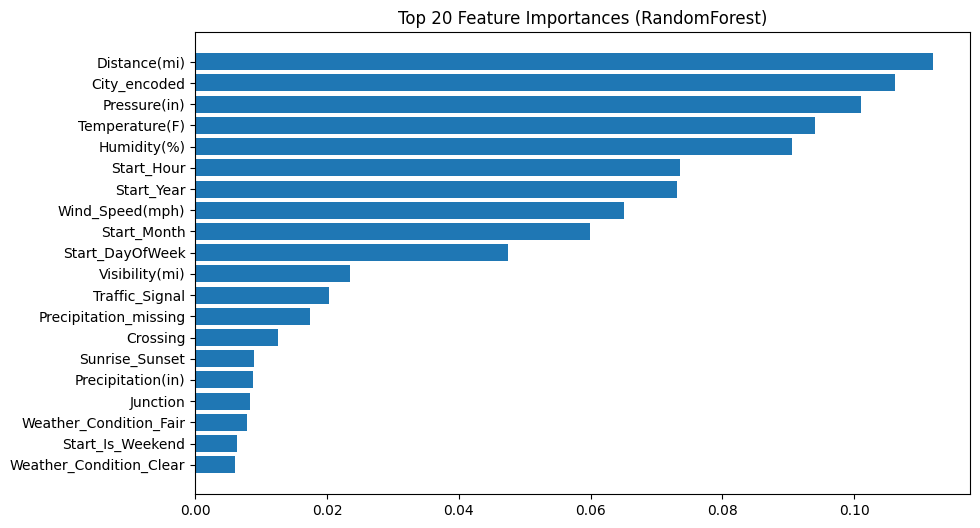

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
# Split features and target
X = df.drop(columns=['Severity']) # Dataset
y = df['Severity'] # what we want to predict


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=132,
    stratify=y
)
# Train the model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=132,
    n_jobs=-1
)

model.fit(X_train, y_train)
# Use the model
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
cm = confusion_matrix(y_test, y_pred)
print(cm)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\nTop 20 Important Features:\n")
print(feature_importance.head(20))

# Plot top features
top = feature_importance.head(20)

plt.figure(figsize=(10,6))
plt.barh(top['feature'][::-1], top['importance'][::-1])
plt.title("Top 20 Feature Importances (RandomForest)")
plt.show()


# The model has 81% Accuracy but this is misleading because it scores well on the most frequenct severity class (2) but performs very poorly for Severity 4 which is rare, 5% recall, the imbalance is hindering our 
# prediction, for the next iteration of models we will try SMOTE to oversample the rarer classes see if it performs better

Severity
2    312064
3     66422
4     10153
1      3366
Name: count, dtype: int64
Severity
2    312064
3    312064
4    312064
1    312064
Name: count, dtype: int64
Accuracy: 0.7953817269035326

Classification Report:

              precision    recall  f1-score   support

           1       0.38      0.42      0.40       842
           2       0.87      0.89      0.88     78017
           3       0.49      0.47      0.48     16605
           4       0.31      0.16      0.21      2538

    accuracy                           0.80     98002
   macro avg       0.51      0.49      0.49     98002
weighted avg       0.79      0.80      0.79     98002


Confusion Matrix:

[[  356   429    54     3]
 [  389 69433  7548   647]
 [  177  8396  7746   286]
 [    5  1743   376   414]]

Top 20 Important Features:

                            feature  importance
0                      Distance(mi)    0.183084
22                       Start_Year    0.130490
26                     City_encoded    0.08

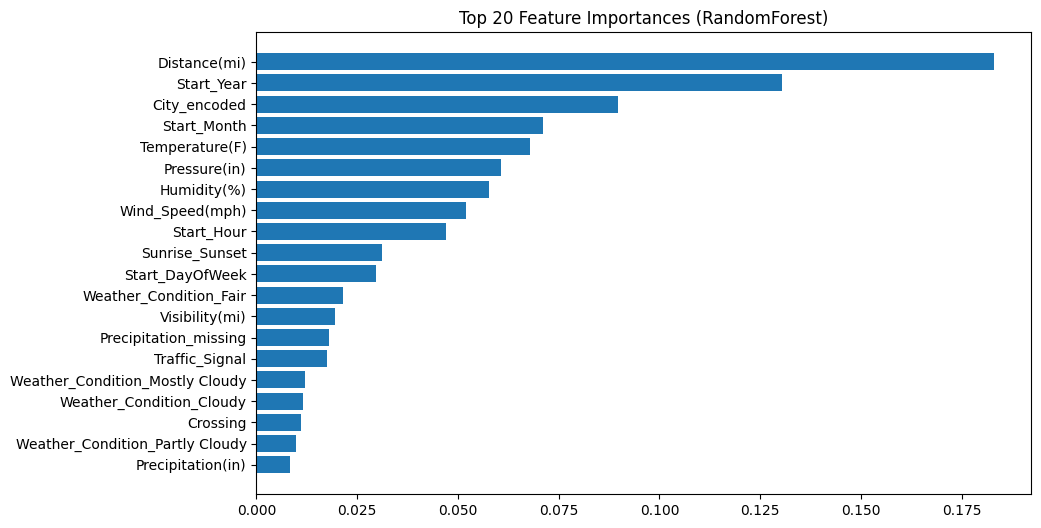

In [22]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=132)
# Do smote on the training data not test
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(y_train.value_counts())
print(y_train_resampled.value_counts())

model = RandomForestClassifier(
    n_estimators=100,
    random_state=132,
    n_jobs=-1
)

model.fit(X_train_resampled, y_train_resampled)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
cm = confusion_matrix(y_test, y_pred)
print(cm)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\nTop 20 Important Features:\n")
print(feature_importance.head(20))

# Plot top features
top = feature_importance.head(20)

plt.figure(figsize=(10,6))
plt.barh(top['feature'][::-1], top['importance'][::-1])
plt.title("Top 20 Feature Importances (RandomForest)")
plt.show()

# So Accuracy dropped slightly and the top variables stayed the same altough in different orders but this improved recall and f1 scores for class 4 and 1 significantly which were the ones that class 3 and 2 dominated mostly 2.
# The model can now detect some severe accidents and very low severity ones but it still struggles, and as we see in the confusion matrix even when wrong we also classify severity 4 more as severity 3 than as severity 2
# although we still classify alot of severity 4 in severity 2, ideally we would like to classify all severity 4 in severity 4 but the next best thing is to predict severity 4 in class severity 3

In [23]:
# We see from the previous models that time plays a big role in predicting the severity but they are mixing randomly across all years
# The model could be learning from past and future mixed together and this could be a problem
# So what we will do now is use past data as train data and test data as future data and apply SMOTE only to the past data

In [24]:
# Out-of-time (OOT) split: train on 2016–2021, test on 2022–2023
# This avoids temporal leakage — the model only ever sees past data during training,
# which is how it would work in a real deployment scenario.
# Start_Year was already extracted before we dropped Start_Time so we still have it.

X = df.drop(columns=['Severity'])
y = df['Severity']

train_mask = df['Start_Year'] <= 2021
test_mask  = df['Start_Year'] >= 2022

X_train_oot = X[train_mask]
y_train_oot = y[train_mask]

X_test_oot  = X[test_mask]
y_test_oot  = y[test_mask]

print("Train size:", len(X_train_oot), "| Years:", sorted(df.loc[train_mask, 'Start_Year'].unique()))
print("Test size: ", len(X_test_oot),  "| Years:", sorted(df.loc[test_mask,  'Start_Year'].unique()))

print("\nTrain class distribution (%):")
print((y_train_oot.value_counts(normalize=True) * 100).round(2).sort_index())

print("\nTest class distribution (%):")
print((y_test_oot.value_counts(normalize=True) * 100).round(2).sort_index())

Train size: 363286 | Years: [np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021)]
Test size:  126721 | Years: [np.int32(2022), np.int32(2023)]

Train class distribution (%):
Severity
1     0.51
2    75.37
3    21.48
4     2.65
Name: proportion, dtype: float64

Test class distribution (%):
Severity
1     1.86
2    91.77
3     3.94
4     2.43
Name: proportion, dtype: float64


Accuracy: 0.7630542688267927

Classification Report:

              precision    recall  f1-score   support

           1       0.00      0.00      0.00      2361
           2       0.96      0.79      0.86    116288
           3       0.49      0.75      0.59      4995
           4       0.07      0.53      0.12      3077

    accuracy                           0.76    126721
   macro avg       0.38      0.52      0.39    126721
weighted avg       0.90      0.76      0.82    126721


Confusion Matrix:

[[    0  1691   648    22]
 [    1 91334  3235 21718]
 [    0  1025  3726   244]
 [    0  1424    18  1635]]

Computing permutation importance (this may take a moment)...

Top 20 Important Features:

                                      feature  importance
0                                Distance(mi)    0.147401
26                               City_encoded    0.021971
19                                 Start_Hour    0.013416
17                             Traffic_Signal    0.012669
3

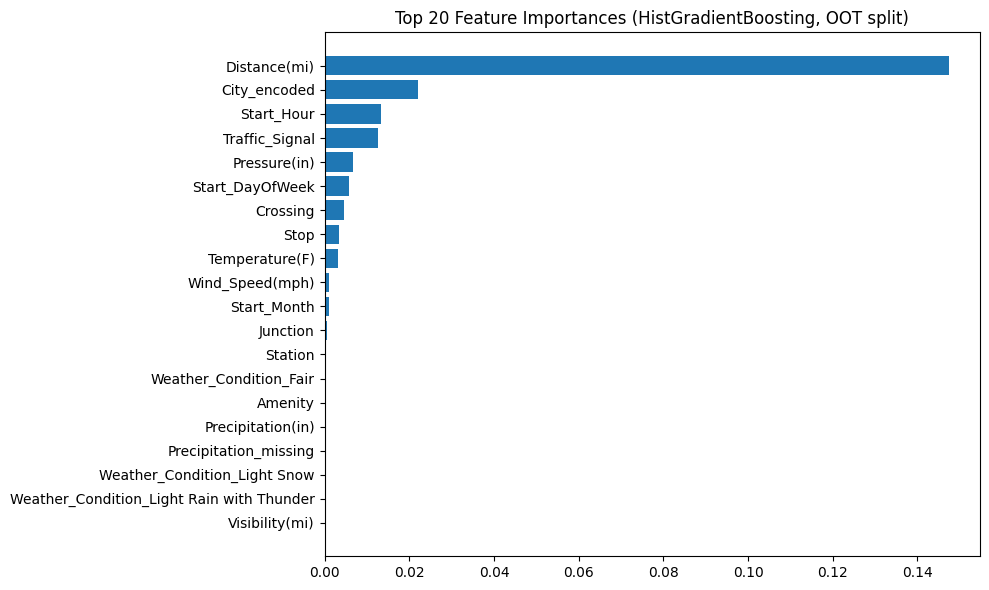

In [25]:
# Using HistGradientBoostingClassifier from scikit-learn — no system dependencies needed.
# It's a gradient boosting implementation similar to LightGBM/XGBoost,
# fast on large datasets, and supports class_weight='balanced' natively.

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd

hgb_model = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=63,      # equivalent to num_leaves=63 in LightGBM
    class_weight='balanced',
    random_state=132
)

hgb_model.fit(X_train_oot, y_train_oot)

y_pred_oot = hgb_model.predict(X_test_oot)

print("Accuracy:", accuracy_score(y_test_oot, y_pred_oot))
print("\nClassification Report:\n")
print(classification_report(y_test_oot, y_pred_oot))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test_oot, y_pred_oot))

# Feature importance via permutation importance (HistGradientBoosting doesn't have .feature_importances_)
from sklearn.inspection import permutation_importance

print("\nComputing permutation importance (this may take a moment)...")
perm_imp = permutation_importance(
    hgb_model, X_test_oot, y_test_oot,
    n_repeats=5,
    random_state=132,
    n_jobs=-1,
    scoring='f1_macro'      # macro F1 is more meaningful than accuracy given class imbalance
)

feat_imp = pd.DataFrame({
    'feature': X_train_oot.columns,
    'importance': perm_imp.importances_mean
}).sort_values('importance', ascending=False)

print("\nTop 20 Important Features:\n")
print(feat_imp.head(20))

top = feat_imp.head(20)
plt.figure(figsize=(10, 6))
plt.barh(top['feature'][::-1], top['importance'][::-1])
plt.title("Top 20 Feature Importances (HistGradientBoosting, OOT split)")
plt.tight_layout()
plt.show()

In [26]:
# Check class distribution across years to understand the shift
print(df.groupby('Start_Year')['Severity'].value_counts(normalize=True).unstack().round(3))

Severity        1      2      3      4
Start_Year                            
2016        0.001  0.660  0.306  0.033
2017        0.000  0.642  0.324  0.033
2018        0.000  0.645  0.327  0.028
2019        0.000  0.719  0.251  0.029
2020        0.024  0.790  0.160  0.027
2021        0.000  0.885  0.096  0.019
2022        0.021  0.910  0.045  0.024
2023          NaN  0.971    NaN  0.029


Train binary distribution (%):
Severity
0    75.87
1    24.13
Name: proportion, dtype: float64

Test binary distribution (%):
Severity
0    93.63
1     6.37
Name: proportion, dtype: float64

Accuracy: 0.9321659393470696

Classification Report:

              precision    recall  f1-score   support

   Low (1-2)       0.96      0.96      0.96    118649
  High (3-4)       0.47      0.47      0.47      8072

    accuracy                           0.93    126721
   macro avg       0.72      0.71      0.72    126721
weighted avg       0.93      0.93      0.93    126721


Confusion Matrix:

[[114363   4286]
 [  4310   3762]]

Computing permutation importance...

Top 20 Important Features:

                     feature  importance
0               Distance(mi)    0.208296
26              City_encoded    0.019441
19                Start_Hour    0.017051
17            Traffic_Signal    0.014545
9                   Crossing    0.008329
20           Start_DayOfWeek    0.007194
3               Pres

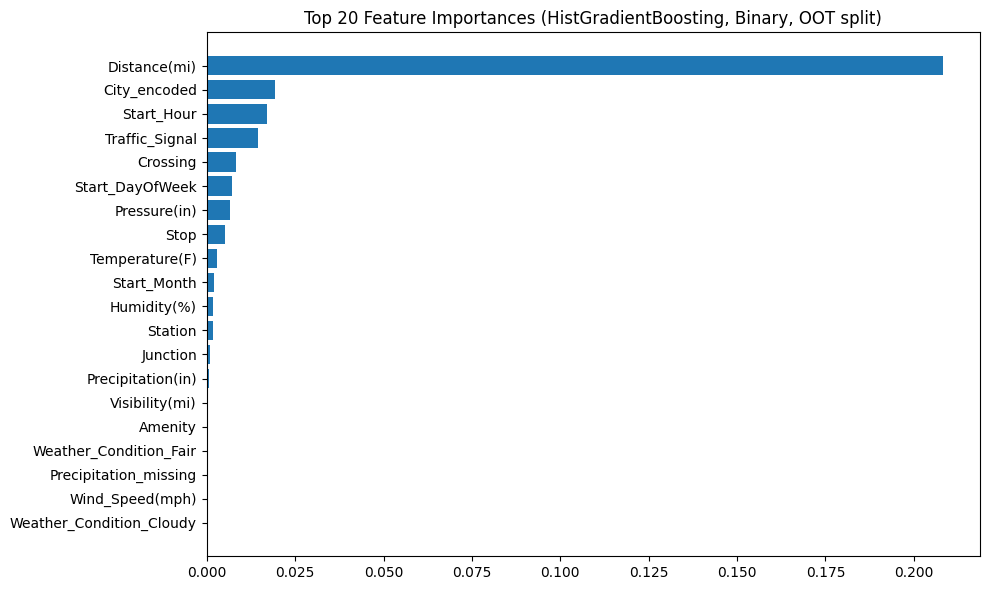

In [27]:
# Given the clear distribution shift in severity labeling across years,
# we reframe as binary classification: low severity (1-2) vs high severity (3-4).
# This is more robust to the labeling inconsistency and more practically meaningful.

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd

# Remap: 1,2 → 0 (low), 3,4 → 1 (high)
y_train_bin = y_train_oot.map({1: 0, 2: 0, 3: 1, 4: 1})
y_test_bin  = y_test_oot.map({1: 0, 2: 0, 3: 1, 4: 1})

print("Train binary distribution (%):")
print((y_train_bin.value_counts(normalize=True) * 100).round(2).sort_index())
print("\nTest binary distribution (%):")
print((y_test_bin.value_counts(normalize=True) * 100).round(2).sort_index())

hgb_binary = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=63,
    class_weight='balanced',
    random_state=132
)

hgb_binary.fit(X_train_oot, y_train_bin)
y_pred_bin = hgb_binary.predict(X_test_oot)

print("\nAccuracy:", accuracy_score(y_test_bin, y_pred_bin))
print("\nClassification Report:\n")
print(classification_report(y_test_bin, y_pred_bin, target_names=['Low (1-2)', 'High (3-4)']))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test_bin, y_pred_bin))

# Permutation importance
from sklearn.inspection import permutation_importance

print("\nComputing permutation importance...")
perm_imp = permutation_importance(
    hgb_binary, X_test_oot, y_test_bin,
    n_repeats=5,
    random_state=132,
    n_jobs=-1,
    scoring='f1_macro'
)

feat_imp = pd.DataFrame({
    'feature': X_train_oot.columns,
    'importance': perm_imp.importances_mean
}).sort_values('importance', ascending=False)

print("\nTop 20 Important Features:\n")
print(feat_imp.head(20))

top = feat_imp.head(20)
plt.figure(figsize=(10, 6))
plt.barh(top['feature'][::-1], top['importance'][::-1])
plt.title("Top 20 Feature Importances (HistGradientBoosting, Binary, OOT split)")
plt.tight_layout()
plt.show()

The binary OOT model already shows improvement but defaults to a 0.5 decision threshold which is not well suited for imbalanced classes. With high severity accidents making up only 6% of the test set, the model is biased towards predicting low severity. In a real world context, missing a high severity accident (false negative) is far more costly than a false alarm (false positive), so we want to tune the threshold to reflect that. By lowering the threshold we accept more false positives in exchange for catching more true high severity cases, optimizing for F1 on the minority class.

Best threshold: 0.49
Best F1 (high severity): 0.4671


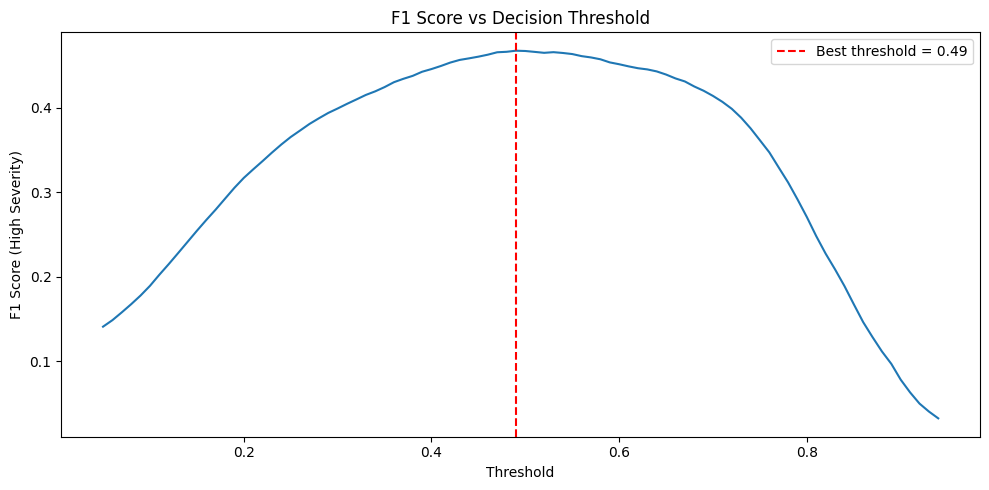


Accuracy: 0.9310690414374887

Classification Report:

              precision    recall  f1-score   support

   Low (1-2)       0.96      0.96      0.96    118649
  High (3-4)       0.46      0.47      0.47      8072

    accuracy                           0.93    126721
   macro avg       0.71      0.72      0.72    126721
weighted avg       0.93      0.93      0.93    126721


Confusion Matrix:

[[114158   4491]
 [  4244   3828]]


In [28]:
# Threshold tuning for the binary OOT model
# Default threshold of 0.5 is too conservative for the minority class (High severity)
# given the distribution shift between train and test periods.
# We optimize the threshold to maximize F1 for the high severity class.

from sklearn.metrics import f1_score, precision_recall_curve
import numpy as np

# Get predicted probabilities instead of hard class predictions
y_proba = hgb_binary.predict_proba(X_test_oot)[:, 1]  # probability of high severity

# Try a range of thresholds and find the one that maximizes F1 for high severity
thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    f1_scores.append(f1_score(y_test_bin, y_pred_t, pos_label=1))

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print(f"Best threshold: {best_threshold:.2f}")
print(f"Best F1 (high severity): {best_f1:.4f}")

# Plot F1 vs threshold
plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores)
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best threshold = {best_threshold:.2f}')
plt.xlabel("Threshold")
plt.ylabel("F1 Score (High Severity)")
plt.title("F1 Score vs Decision Threshold")
plt.legend()
plt.tight_layout()
plt.show()

# Evaluate with the best threshold
y_pred_tuned = (y_proba >= best_threshold).astype(int)

print("\nAccuracy:", accuracy_score(y_test_bin, y_pred_tuned))
print("\nClassification Report:\n")
print(classification_report(y_test_bin, y_pred_tuned, target_names=['Low (1-2)', 'High (3-4)']))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test_bin, y_pred_tuned))

The threshold tuning shows that the optimal threshold is 0.49 — nearly identical to the default 0.5 — meaning the model's predicted probabilities are not separating the classes well enough for tuning to make a meaningful difference. This confirms that the distribution shift between train and test is too large to overcome with threshold adjustment alone, so we try switching to a random 80/20 split.

In [29]:
# Given the significant distribution shift between train and test years,
# the OOT split is not viable for this dataset. The severity labeling changed
# substantially over time (class 3 going from 33% in 2016 to near 0% in 2023),
# which is a data collection artifact rather than a real world trend.
# We therefore switch to a random 80/20 split with binary labels, and note the
# temporal distribution shift as a key finding and limitation in the report.

from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import pandas as pd

# Binary target: low severity (1-2) → 0, high severity (3-4) → 1
y_binary = y.map({1: 0, 2: 0, 3: 1, 4: 1})

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X, y_binary,
    test_size=0.2,
    random_state=132,
    stratify=y_binary
)

print("Train class distribution (%):")
print((y_train_b.value_counts(normalize=True) * 100).round(2).sort_index())
print("\nTest class distribution (%):")
print((y_test_b.value_counts(normalize=True) * 100).round(2).sort_index())

# Apply SMOTE to training data only
smote = SMOTE(random_state=132)
X_train_b_res, y_train_b_res = smote.fit_resample(X_train_b, y_train_b)

print("\nAfter SMOTE:")
print(pd.Series(y_train_b_res).value_counts().sort_index())

# Train HistGradientBoostingClassifier
hgb_binary_rs = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=63,
    class_weight='balanced',
    random_state=132
)

hgb_binary_rs.fit(X_train_b_res, y_train_b_res)
y_pred_b = hgb_binary_rs.predict(X_test_b)

print("\nAccuracy:", accuracy_score(y_test_b, y_pred_b))
print("\nClassification Report:\n")
print(classification_report(y_test_b, y_pred_b, target_names=['Low (1-2)', 'High (3-4)']))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test_b, y_pred_b))

Train class distribution (%):
Severity
0    80.47
1    19.53
Name: proportion, dtype: float64

Test class distribution (%):
Severity
0    80.47
1    19.53
Name: proportion, dtype: float64

After SMOTE:
Severity
0    315431
1    315431
Name: count, dtype: int64

Accuracy: 0.836574763780331

Classification Report:

              precision    recall  f1-score   support

   Low (1-2)       0.87      0.93      0.90     78858
  High (3-4)       0.61      0.45      0.52     19144

    accuracy                           0.84     98002
   macro avg       0.74      0.69      0.71     98002
weighted avg       0.82      0.84      0.83     98002


Confusion Matrix:

[[73451  5407]
 [10609  8535]]


In [30]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test_b, y_pred_b, target_names=['Low (1-2)', 'High (3-4)']))

              precision    recall  f1-score   support

   Low (1-2)       0.87      0.93      0.90     78858
  High (3-4)       0.61      0.45      0.52     19144

    accuracy                           0.84     98002
   macro avg       0.74      0.69      0.71     98002
weighted avg       0.82      0.84      0.83     98002



Best threshold (macro F1): 0.41


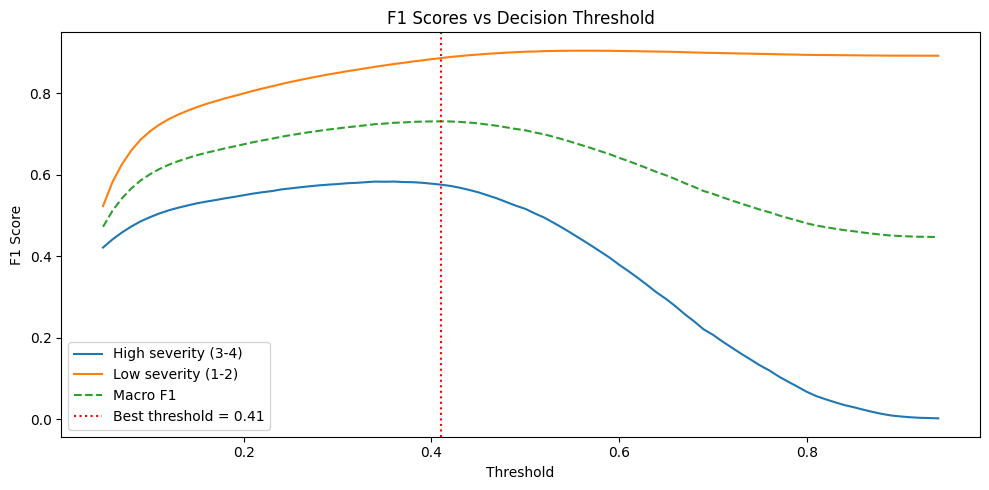


Accuracy: 0.8201873431154466

Classification Report:

              precision    recall  f1-score   support

   Low (1-2)       0.90      0.87      0.89     78858
  High (3-4)       0.53      0.62      0.58     19144

    accuracy                           0.82     98002
   macro avg       0.72      0.75      0.73     98002
weighted avg       0.83      0.82      0.83     98002


Confusion Matrix:

[[68440 10418]
 [ 7204 11940]]


In [31]:
# The random split model has better calibrated probabilities than the OOT version
# since SMOTE balanced the training data. We therefore try threshold tuning again
# to see if we can improve recall on high severity accidents.

import numpy as np
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

y_proba_b = hgb_binary_rs.predict_proba(X_test_b)[:, 1]

thresholds = np.arange(0.05, 0.95, 0.01)
f1_high, f1_low, f1_macro = [], [], []

for t in thresholds:
    y_pred_t = (y_proba_b >= t).astype(int)
    f1_high.append(f1_score(y_test_b, y_pred_t, pos_label=1))
    f1_low.append(f1_score(y_test_b, y_pred_t, pos_label=0))
    f1_macro.append(f1_score(y_test_b, y_pred_t, average='macro'))

best_threshold = thresholds[np.argmax(f1_macro)]
print(f"Best threshold (macro F1): {best_threshold:.2f}")

# Plot all three curves
plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_high, label='High severity (3-4)')
plt.plot(thresholds, f1_low, label='Low severity (1-2)')
plt.plot(thresholds, f1_macro, label='Macro F1', linestyle='--')
plt.axvline(best_threshold, color='red', linestyle=':', label=f'Best threshold = {best_threshold:.2f}')
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Scores vs Decision Threshold")
plt.legend()
plt.tight_layout()
plt.show()

# Final evaluation with best threshold
y_pred_tuned_b = (y_proba_b >= best_threshold).astype(int)

print("\nAccuracy:", accuracy_score(y_test_b, y_pred_tuned_b))
print("\nClassification Report:\n")
print(classification_report(y_test_b, y_pred_tuned_b, target_names=['Low (1-2)', 'High (3-4)']))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test_b, y_pred_tuned_b))

Computing permutation importance (this may take a moment)...

Top 20 Important Features:

                            feature  importance       std
22                       Start_Year    0.124792  0.001223
0                      Distance(mi)    0.101395  0.000874
37           Weather_Condition_Fair    0.078606  0.000971
20                  Start_DayOfWeek    0.055959  0.000948
23                 Start_Is_Weekend    0.045434  0.000448
26                     City_encoded    0.043084  0.001225
31         Weather_Condition_Cloudy    0.030952  0.000458
21                      Start_Month    0.025922  0.001090
88  Weather_Condition_Mostly Cloudy    0.025358  0.000468
94  Weather_Condition_Partly Cloudy    0.020851  0.000392
17                   Traffic_Signal    0.018782  0.000468
9                          Crossing    0.016035  0.000409
30          Weather_Condition_Clear    0.013450  0.000345
19                       Start_Hour    0.011632  0.000527
5                   Wind_Speed(mph)    0

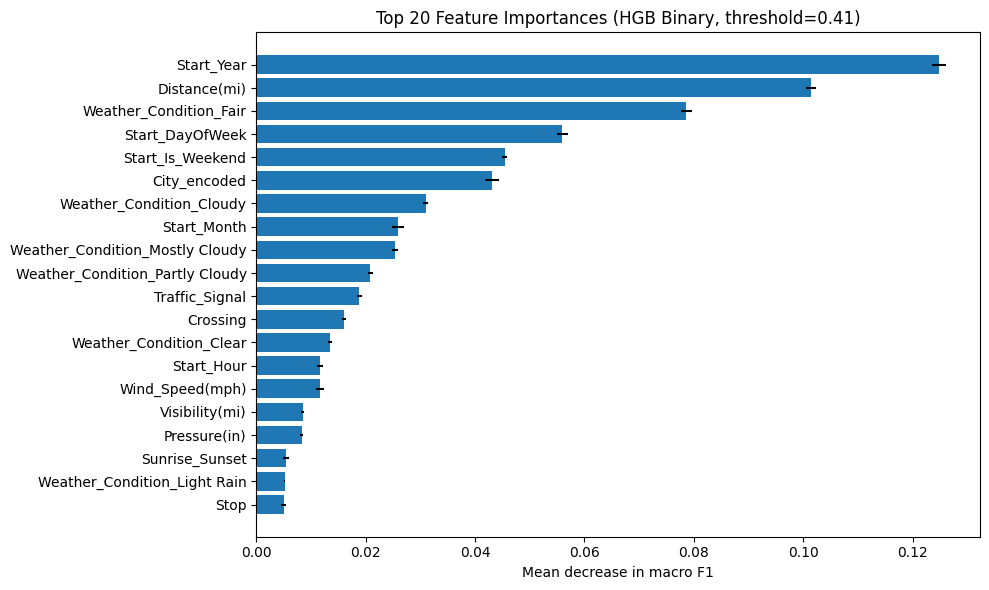

In [47]:
# Permutation importance for the final tuned binary model.
# We use permutation importance since HistGradientBoostingClassifier does not
# expose feature_importances_ directly like Random Forest does.
# Scoring on macro F1 to reflect performance on both classes equally.

from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd

print("Computing permutation importance (this may take a moment)...")
perm_imp = permutation_importance(
    hgb_binary_rs, X_test_b, y_test_b,
    n_repeats=5,
    random_state=132,
    n_jobs=-1,
    scoring='f1_macro'
)

feat_imp = pd.DataFrame({
    'feature': X_train_b_res.columns,
    'importance': perm_imp.importances_mean,
    'std': perm_imp.importances_std
}).sort_values('importance', ascending=False)

print("\nTop 20 Important Features:\n")
print(feat_imp.head(20))

top = feat_imp.head(20)
plt.figure(figsize=(10, 6))
plt.barh(top['feature'][::-1], top['importance'][::-1], xerr=top['std'][::-1])
plt.title("Top 20 Feature Importances (HGB Binary, threshold=0.41)")
plt.xlabel("Mean decrease in macro F1")
plt.tight_layout()
plt.savefig('Top20Features.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# Looking at the feature importance results, Start_Year is the most important feature
# by a significant margin. We know from our earlier analysis that
# severity labeling changed dramatically over time (class 3 dropping from 33% in 2016
# to near 0% in 2023), meaning the model is partly learning to predict severity based
# on what year the accident happened rather than the actual conditions of the accident.
# This is a form of data leakage from the labeling artifact we identified earlier.
# A model that relies on the year to predict severity would be useless in deployment
# since we would not be feeding it a year to get a prediction, we want it to predict
# based on weather, time of day, road conditions and so on.
# We therefore try removing Start_Year and compare performance to see how much
# we lose, if anything, by removing it. If the drop is small we keep it out since
# the model is more honest and more useful without it.

X_no_year = X.drop(columns=['Start_Year'])

X_train_ny, X_test_ny, y_train_ny, y_test_ny = train_test_split(
    X_no_year, y_binary,
    test_size=0.2,
    random_state=132,
    stratify=y_binary
)

# Apply SMOTE to training data only
smote_ny = SMOTE(random_state=132)
X_train_ny_res, y_train_ny_res = smote_ny.fit_resample(X_train_ny, y_train_ny)

hgb_no_year = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=63,
    class_weight='balanced',
    random_state=132
)

hgb_no_year.fit(X_train_ny_res, y_train_ny_res)

# Apply the same threshold we found earlier (0.41)
y_proba_ny = hgb_no_year.predict_proba(X_test_ny)[:, 1]
y_pred_ny = (y_proba_ny >= 0.41).astype(int)

print("Results without Start_Year (threshold=0.41):\n")
print("Accuracy:", accuracy_score(y_test_ny, y_pred_ny))
print("\nClassification Report:\n")
print(classification_report(y_test_ny, y_pred_ny, target_names=['Low (1-2)', 'High (3-4)']))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test_ny, y_pred_ny))

Results without Start_Year (threshold=0.41):

Accuracy: 0.8158813085447236

Classification Report:

              precision    recall  f1-score   support

   Low (1-2)       0.89      0.88      0.89     78858
  High (3-4)       0.53      0.54      0.53     19144

    accuracy                           0.82     98002
   macro avg       0.71      0.71      0.71     98002
weighted avg       0.82      0.82      0.82     98002


Confusion Matrix:

[[69629  9229]
 [ 8815 10329]]


Small but noticeable drop. Dropping Start_Year hurts performance enough to keep it in, macro F1 drops from 0.73 to 0.71 high severity recall from 62% to 54%. While we know the year partially reflects the labeling artifact, it also captures real changes over time such as road conditions, traffic patterns and reporting standards. It is probably best for us to keep it in the final model and note it as a limitation in the report.

In [34]:
# 1. Severity distribution
df_orig = vehicles.copy()
print(df_orig['Severity'].value_counts().sort_index())

Severity
1      4274
2    398142
3     84520
4     13064
Name: count, dtype: int64


In [35]:
# 2. Accidents per year
print(df['Start_Year'].value_counts().sort_index())

Start_Year
2016     26333
2017     45796
2018     56497
2019     60942
2020     74168
2021     99550
2022    111363
2023     15358
Name: count, dtype: int64


In [36]:
# 3. Severity by year (the table we already have)
print(df.groupby('Start_Year')['Severity'].value_counts(normalize=True).unstack().round(3))

Severity        1      2      3      4
Start_Year                            
2016        0.001  0.660  0.306  0.033
2017        0.000  0.642  0.324  0.033
2018        0.000  0.645  0.327  0.028
2019        0.000  0.719  0.251  0.029
2020        0.024  0.790  0.160  0.027
2021        0.000  0.885  0.096  0.019
2022        0.021  0.910  0.045  0.024
2023          NaN  0.971    NaN  0.029


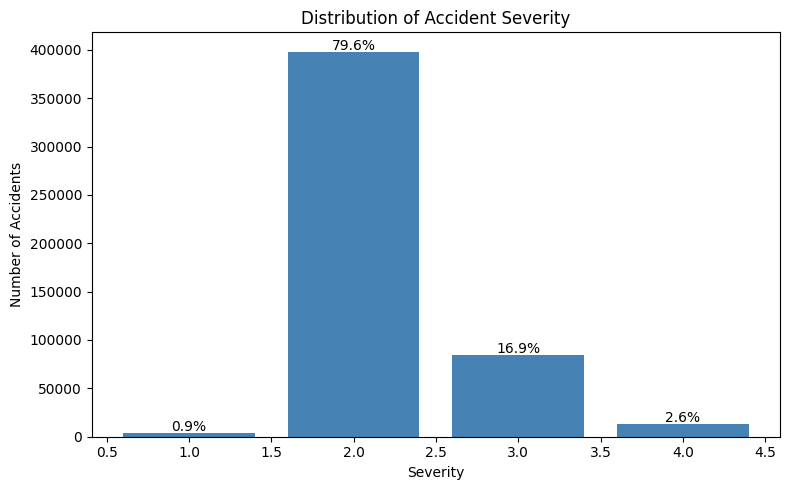

In [37]:
# Plot 1: Severity distribution
import matplotlib.pyplot as plt
import pandas as pd

severity_counts = vehicles['Severity'].value_counts().sort_index()
severity_pct = severity_counts / severity_counts.sum() * 100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(severity_counts.index, severity_counts.values, color='steelblue')
ax.set_xlabel("Severity")
ax.set_ylabel("Number of Accidents")
ax.set_title("Distribution of Accident Severity")
for bar, pct in zip(bars, severity_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f'{pct:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('Accident_severity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

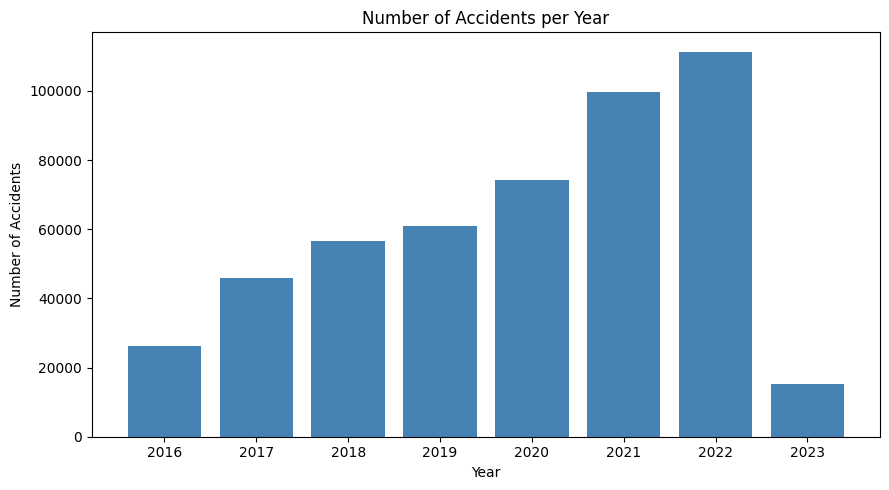

In [38]:
# Plot 2: Accidents per year
year_counts = df['Start_Year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(year_counts.index, year_counts.values, color='steelblue')
ax.set_xlabel("Year")
ax.set_ylabel("Number of Accidents")
ax.set_title("Number of Accidents per Year")
ax.set_xticks(year_counts.index)
plt.tight_layout()
plt.savefig('Accident_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

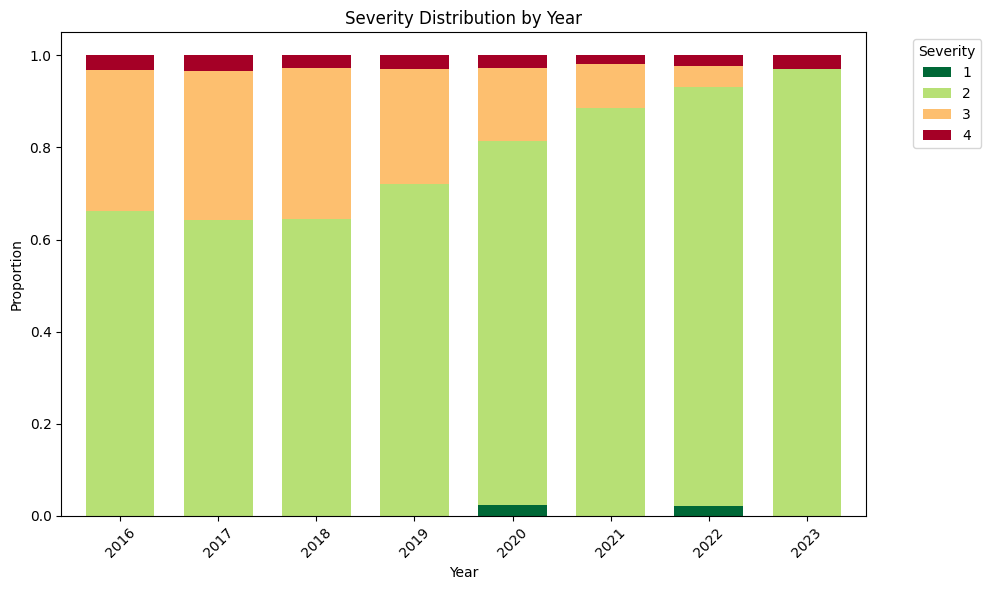

In [39]:
# Plot 3: Severity distribution by year (stacked bar)
sev_year = df.groupby('Start_Year')['Severity'].value_counts(normalize=True).unstack().fillna(0)

sev_year.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    colormap='RdYlGn_r',
    width=0.7
)
plt.title("Severity Distribution by Year")
plt.xlabel("Year")
plt.ylabel("Proportion")
plt.legend(title="Severity", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('severity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Reduced randomized search - fewer iterations and 3-fold CV to keep runtime manageable
# Cross validation on the full SMOTE dataset is too slow given its size.
# We instead run the search on a stratified sample of the training data to keep
# runtime manageable while still getting a reasonable estimate of performance.

from sklearn.model_selection import RandomizedSearchCV, StratifiedShuffleSplit
from sklearn.ensemble import HistGradientBoostingClassifier
import pandas as pd

# Sample 150k rows from the resampled training data, stratified by class
sample_idx = pd.Series(y_train_b_res).groupby(y_train_b_res).apply(
    lambda x: x.sample(75000, random_state=132)
).index.get_level_values(1)

X_train_sample = X_train_b_res.iloc[sample_idx]
y_train_sample = y_train_b_res.iloc[sample_idx]

print("Sample class distribution:")
print(pd.Series(y_train_sample).value_counts())

param_dist = {
    'learning_rate':    [0.05, 0.1, 0.2],
    'max_leaf_nodes':   [31, 63, 127],
    'min_samples_leaf': [20, 50],
}

hgb_search = HistGradientBoostingClassifier(
    max_iter=200,
    class_weight='balanced',
    random_state=132
)

search = RandomizedSearchCV(
    hgb_search,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='f1_macro',
    random_state=132,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train_sample, y_train_sample)

print("Best parameters:", search.best_params_)
print("Best cross-validated macro F1:", search.best_score_.round(4))

# Evaluate best model on full test set
y_proba_tuned = search.best_estimator_.predict_proba(X_test_b)[:, 1]
y_pred_tuned = (y_proba_tuned >= 0.41).astype(int)

print("\nAccuracy:", accuracy_score(y_test_b, y_pred_tuned))
print("\nClassification Report:\n")
print(classification_report(y_test_b, y_pred_tuned, target_names=['Low (1-2)', 'High (3-4)']))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test_b, y_pred_tuned))

Sample class distribution:
Severity
0    75000
1    75000
Name: count, dtype: int64
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters: {'min_samples_leaf': 50, 'max_leaf_nodes': 127, 'learning_rate': 0.1}
Best cross-validated macro F1: 0.882

Accuracy: 0.8190138976755577

Classification Report:

              precision    recall  f1-score   support

   Low (1-2)       0.90      0.87      0.89     78858
  High (3-4)       0.53      0.60      0.56     19144

    accuracy                           0.82     98002
   macro avg       0.72      0.74      0.72     98002
weighted avg       0.83      0.82      0.82     98002


Confusion Matrix:

[[68829 10029]
 [ 7708 11436]]


In [45]:
print(classification_report(y_test_b, y_pred_tuned_b, target_names=['Low (1-2)', 'High (3-4)']))
print(confusion_matrix(y_test_b, y_pred_tuned_b))

              precision    recall  f1-score   support

   Low (1-2)       0.90      0.87      0.89     78858
  High (3-4)       0.53      0.62      0.58     19144

    accuracy                           0.82     98002
   macro avg       0.72      0.75      0.73     98002
weighted avg       0.83      0.82      0.83     98002

[[68440 10418]
 [ 7204 11940]]


In [46]:
# Just need the macro F1 and high severity F1 from the SMOTE RF model
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=['1', '2', '3', '4']))

              precision    recall  f1-score   support

           1       0.38      0.42      0.40       842
           2       0.87      0.89      0.88     78017
           3       0.49      0.47      0.48     16605
           4       0.31      0.16      0.21      2538

    accuracy                           0.80     98002
   macro avg       0.51      0.49      0.49     98002
weighted avg       0.79      0.80      0.79     98002



   State    Total  Accuracy  High_Recall  High_Count
9     GA   2255.0     0.789        0.765       969.0
15    KY    418.0     0.744        0.758       182.0
37    RI    225.0     0.684        0.757       103.0
21    MN   2413.0     0.842        0.756       398.0
20    MI   2048.0     0.768        0.739       601.0
4     CO   1200.0     0.778        0.734       410.0
22    MO    990.0     0.803        0.688       349.0
46    WI    445.0     0.733        0.669       157.0
33    OH   1510.0     0.756        0.668       482.0
3     CA  21946.0     0.824        0.662      3634.0
8     FL  11156.0     0.885        0.652      1501.0
18    MD   1635.0     0.820        0.638       437.0
10    IA    370.0     0.759        0.634       134.0
12    IL   2127.0     0.745        0.627       825.0
45    WA   1458.0     0.731        0.620       437.0
13    IN    858.0     0.774        0.620       266.0
23    MS    202.0     0.837        0.617        60.0
5     CT    950.0     0.774        0.615      

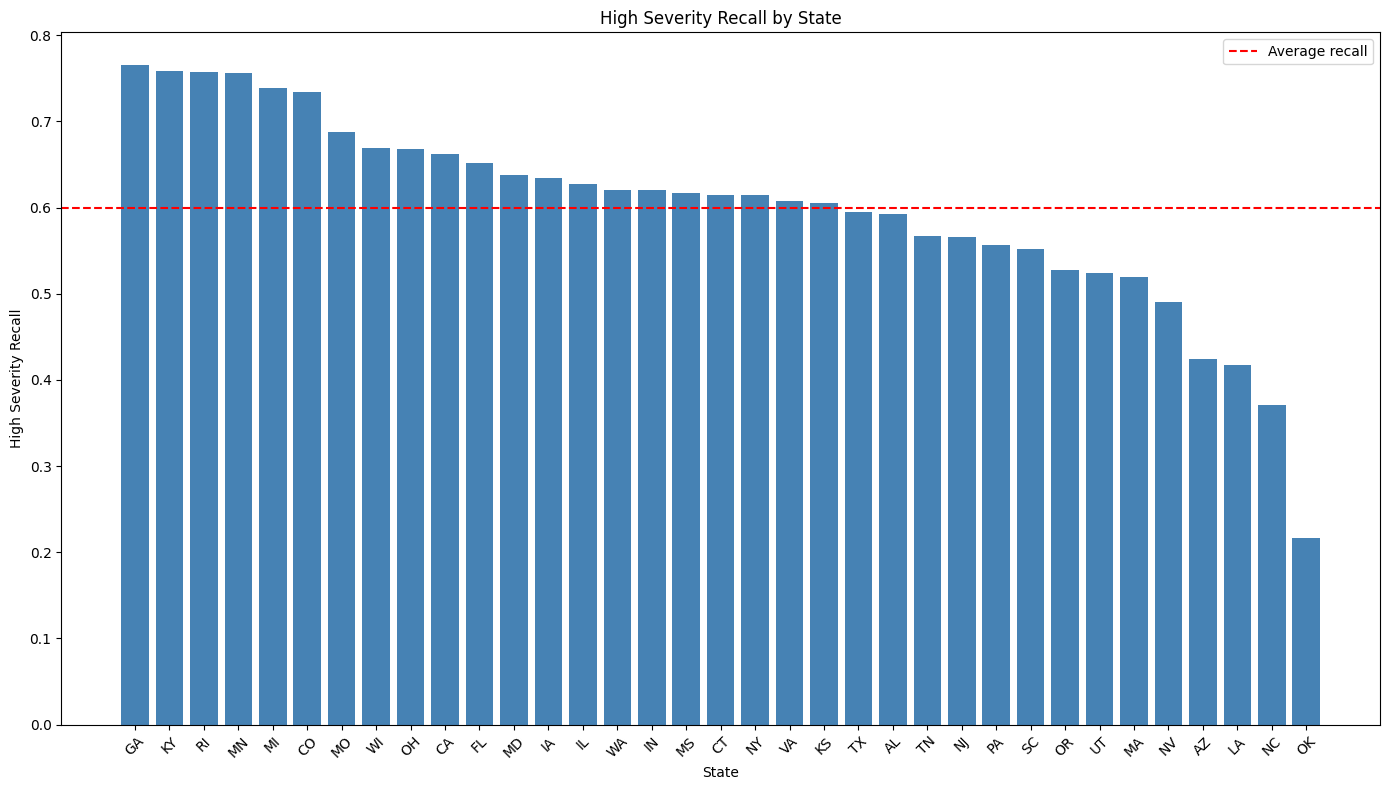

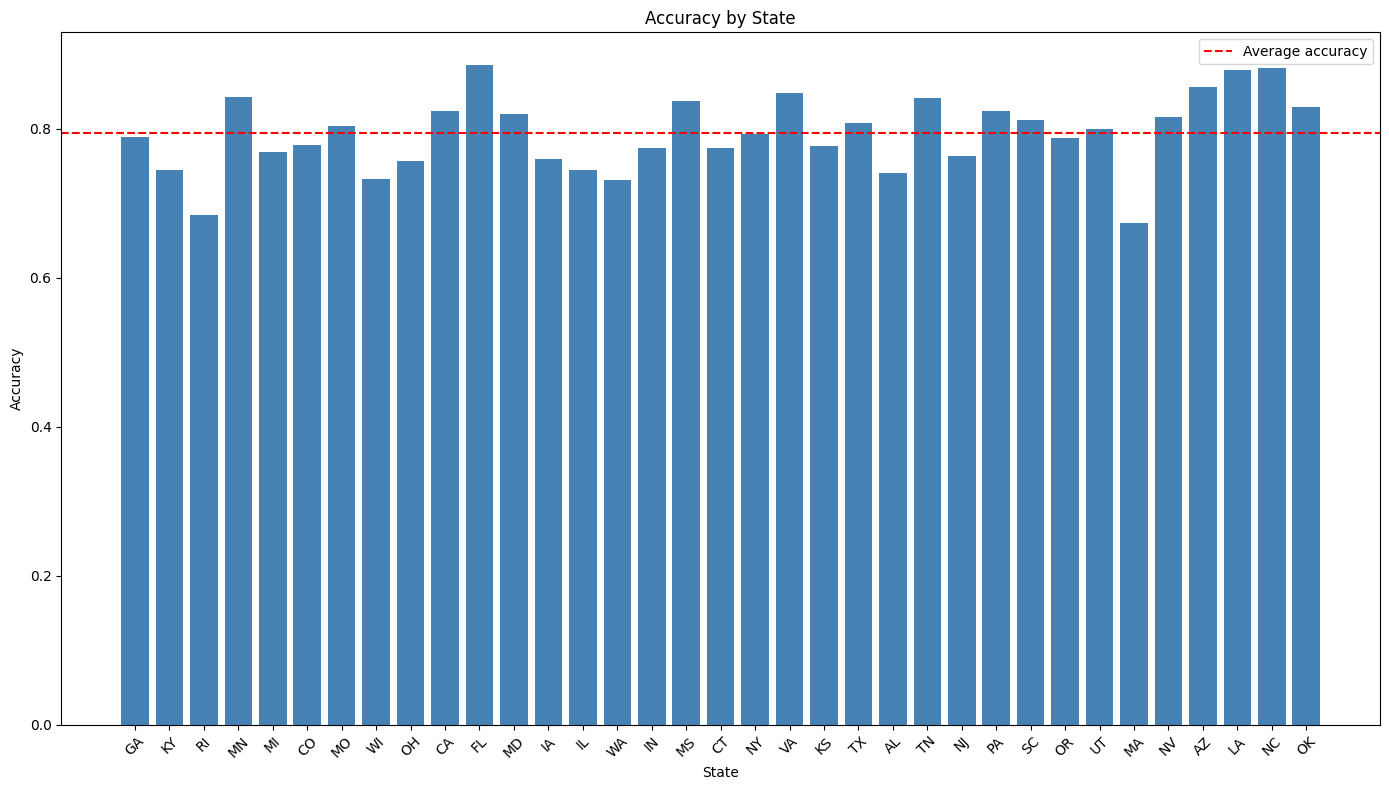

In [50]:
# Analyzing model performance across geographic regions to address research question P2.
# We group the test set predictions by state and calculate accuracy and high severity
# recall for each state to see if there are systematic differences in performance.

# We need to get the state column back for the test set rows
# Since we dropped State during preprocessing we need to get it from the original df
test_indices = X_test_b.index
state_test = vehicles.loc[test_indices, 'State']

region_df = pd.DataFrame({
    'State': state_test,
    'Actual': y_test_b.values,
    'Predicted': y_pred_tuned_b
})

# Calculate accuracy and high severity recall per state
region_results = region_df.groupby('State').apply(
    lambda x: pd.Series({
        'Total': len(x),
        'Accuracy': (x['Actual'] == x['Predicted']).mean().round(3),
        'High_Recall': (x.loc[x['Actual'] == 1, 'Predicted'] == 1).mean().round(3) if (x['Actual'] == 1).sum() > 0 else None,
        'High_Count': (x['Actual'] == 1).sum()
    })
).reset_index()

# Filter out states with very few high severity cases for reliability
region_results_filtered = region_results[region_results['High_Count'] >= 50].sort_values('High_Recall', ascending=False)

print(region_results_filtered.to_string())

# Plot high severity recall by state
plt.figure(figsize=(14, 8))
plt.bar(region_results_filtered['State'], region_results_filtered['High_Recall'], color='steelblue')
plt.axhline(y=region_results_filtered['High_Recall'].mean(), color='red', linestyle='--', label='Average recall')
plt.xlabel("State")
plt.ylabel("High Severity Recall")
plt.title("High Severity Recall by State")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('HighSeverityRecallState.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot accuracy by state
plt.figure(figsize=(14, 8))
plt.bar(region_results_filtered['State'], region_results_filtered['Accuracy'], color='steelblue')
plt.axhline(y=region_results_filtered['Accuracy'].mean(), color='red', linestyle='--', label='Average accuracy')
plt.xlabel("State")
plt.ylabel("Accuracy")
plt.title("Accuracy by State")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
print(region_results_filtered.sort_values('High_Recall', ascending=False).to_string())
print("\nHigh Recall - Max:", region_results_filtered['High_Recall'].max())
print("High Recall - Min:", region_results_filtered['High_Recall'].min())
print("High Recall - Mean:", region_results_filtered['High_Recall'].mean().round(3))
print("High Recall - Std:", region_results_filtered['High_Recall'].std().round(3))

   State    Total  Accuracy  High_Recall  High_Count
9     GA   2255.0     0.789        0.765       969.0
15    KY    418.0     0.744        0.758       182.0
37    RI    225.0     0.684        0.757       103.0
21    MN   2413.0     0.842        0.756       398.0
20    MI   2048.0     0.768        0.739       601.0
4     CO   1200.0     0.778        0.734       410.0
22    MO    990.0     0.803        0.688       349.0
46    WI    445.0     0.733        0.669       157.0
33    OH   1510.0     0.756        0.668       482.0
3     CA  21946.0     0.824        0.662      3634.0
8     FL  11156.0     0.885        0.652      1501.0
18    MD   1635.0     0.820        0.638       437.0
10    IA    370.0     0.759        0.634       134.0
12    IL   2127.0     0.745        0.627       825.0
45    WA   1458.0     0.731        0.620       437.0
13    IN    858.0     0.774        0.620       266.0
23    MS    202.0     0.837        0.617        60.0
5     CT    950.0     0.774        0.615      